In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# This line makes plots appear inside the notebook
%matplotlib inline

In [2]:
import urllib.request

url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
urllib.request.urlretrieve(url, "SMSSpamcollection.tsv")

print("File downloaded successfully!")

File downloaded successfully!


In [3]:
with open("SMSSpamcollection.tsv", "r", encoding="utf-8") as f:
    rawdata = f.read()

rawdata[:500]

"ham\tGo until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...\nham\tOk lar... Joking wif u oni...\nspam\tFree entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's\nham\tU dun say so early hor... U c already then say...\nham\tNah I don't think he goes to usf, he lives around here though\nspam\tFreeMsg Hey there darling it's been 3 week's now and no word bac"

In [4]:
data = pd.read_csv("SMSSpamcollection.tsv", sep="\t", header=None, names=["label", "body_text"])
data.head()

,label,body_text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [6]:
# Function to remove punctuations.
def remove_punc(text):
    nonP_text = "".join([char for char in text if char not in string.punctuation])
    return nonP_text

data["body_text_clean"] = data["body_text"].apply(lambda x: remove_punc(x))

data.head()

,label,body_text,body_text_clean
0,ham,"Go until jurong point, crazy.. Available only ...",Go until jurong point crazy Available only in ...
1,ham,Ok lar... Joking wif u oni...,Ok lar Joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...,U dun say so early hor U c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",Nah I dont think he goes to usf he lives aroun...


In [7]:
import re

#function to apply tokenization
def tokenize(text):
    tokens = re.split("\W+", text)# W+ means all capital, small alphabets and integers 0-9
    return tokens

data["body_text_tokenized"] = data["body_text_clean"].apply(lambda x: tokenize(x))

data.head()

,label,body_text,body_text_clean,body_text_tokenized
0,ham,"Go until jurong point, crazy.. Available only ...",Go until jurong point crazy Available only in ...,"[Go, until, jurong, point, crazy, Available, o..."
1,ham,Ok lar... Joking wif u oni...,Ok lar Joking wif u oni,"[Ok, lar, Joking, wif, u, oni]"
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in 2 a wkly comp to win FA Cup fina...,"[Free, entry, in, 2, a, wkly, comp, to, win, F..."
3,ham,U dun say so early hor... U c already then say...,U dun say so early hor U c already then say,"[U, dun, say, so, early, hor, U, c, already, t..."
4,ham,"Nah I don't think he goes to usf, he lives aro...",Nah I dont think he goes to usf he lives aroun...,"[Nah, I, dont, think, he, goes, to, usf, he, l..."


In [8]:
import nltk
stopwords = nltk.corpus.stopwords.words("english")

def remove_stopwords(token):
    text = [word for word in token if word not in stopwords]# to remove all stopwords
    return text

data["body_text_nonstop"] = data["body_text_tokenized"].apply(lambda x: remove_stopwords(x))
data.head()

,label,body_text,body_text_clean,body_text_tokenized,body_text_nonstop
0,ham,"Go until jurong point, crazy.. Available only ...",Go until jurong point crazy Available only in ...,"[Go, until, jurong, point, crazy, Available, o...","[Go, jurong, point, crazy, Available, bugis, n..."
1,ham,Ok lar... Joking wif u oni...,Ok lar Joking wif u oni,"[Ok, lar, Joking, wif, u, oni]","[Ok, lar, Joking, wif, u, oni]"
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in 2 a wkly comp to win FA Cup fina...,"[Free, entry, in, 2, a, wkly, comp, to, win, F...","[Free, entry, 2, wkly, comp, win, FA, Cup, fin..."
3,ham,U dun say so early hor... U c already then say...,U dun say so early hor U c already then say,"[U, dun, say, so, early, hor, U, c, already, t...","[U, dun, say, early, hor, U, c, already, say]"
4,ham,"Nah I don't think he goes to usf, he lives aro...",Nah I dont think he goes to usf he lives aroun...,"[Nah, I, dont, think, he, goes, to, usf, he, l...","[Nah, I, dont, think, goes, usf, lives, around..."


In [9]:
ps = nltk.PorterStemmer()

def stemming(t_text):
    text = [ps.stem(word) for word in t_text]
    return text

data["body_text_stemmed"] = data["body_text_nonstop"].apply(lambda x: stemming(x))
data.head()

,label,body_text,body_text_clean,body_text_tokenized,body_text_nonstop,body_text_stemmed
0,ham,"Go until jurong point, crazy.. Available only ...",Go until jurong point crazy Available only in ...,"[Go, until, jurong, point, crazy, Available, o...","[Go, jurong, point, crazy, Available, bugis, n...","[go, jurong, point, crazi, avail, bugi, n, gre..."
1,ham,Ok lar... Joking wif u oni...,Ok lar Joking wif u oni,"[Ok, lar, Joking, wif, u, oni]","[Ok, lar, Joking, wif, u, oni]","[ok, lar, joke, wif, u, oni]"
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in 2 a wkly comp to win FA Cup fina...,"[Free, entry, in, 2, a, wkly, comp, to, win, F...","[Free, entry, 2, wkly, comp, win, FA, Cup, fin...","[free, entri, 2, wkli, comp, win, fa, cup, fin..."
3,ham,U dun say so early hor... U c already then say...,U dun say so early hor U c already then say,"[U, dun, say, so, early, hor, U, c, already, t...","[U, dun, say, early, hor, U, c, already, say]","[u, dun, say, earli, hor, u, c, alreadi, say]"
4,ham,"Nah I don't think he goes to usf, he lives aro...",Nah I dont think he goes to usf he lives aroun...,"[Nah, I, dont, think, he, goes, to, usf, he, l...","[Nah, I, dont, think, goes, usf, lives, around...","[nah, i, dont, think, goe, usf, live, around, ..."


In [10]:
wn = nltk.WordNetLemmatizer()

def lemmatizer(t_text):
    text = [wn.lemmatize(word) for word in t_text]
    return text

data["body_text_lemmatized"] = data["body_text_stemmed"].apply(lambda x: lemmatizer(x))
data.head()

,label,body_text,body_text_clean,body_text_tokenized,body_text_nonstop,body_text_stemmed,body_text_lemmatized
0,ham,"Go until jurong point, crazy.. Available only ...",Go until jurong point crazy Available only in ...,"[Go, until, jurong, point, crazy, Available, o...","[Go, jurong, point, crazy, Available, bugis, n...","[go, jurong, point, crazi, avail, bugi, n, gre...","[go, jurong, point, crazi, avail, bugi, n, gre..."
1,ham,Ok lar... Joking wif u oni...,Ok lar Joking wif u oni,"[Ok, lar, Joking, wif, u, oni]","[Ok, lar, Joking, wif, u, oni]","[ok, lar, joke, wif, u, oni]","[ok, lar, joke, wif, u, oni]"
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in 2 a wkly comp to win FA Cup fina...,"[Free, entry, in, 2, a, wkly, comp, to, win, F...","[Free, entry, 2, wkly, comp, win, FA, Cup, fin...","[free, entri, 2, wkli, comp, win, fa, cup, fin...","[free, entri, 2, wkli, comp, win, fa, cup, fin..."
3,ham,U dun say so early hor... U c already then say...,U dun say so early hor U c already then say,"[U, dun, say, so, early, hor, U, c, already, t...","[U, dun, say, early, hor, U, c, already, say]","[u, dun, say, earli, hor, u, c, alreadi, say]","[u, dun, say, earli, hor, u, c, alreadi, say]"
4,ham,"Nah I don't think he goes to usf, he lives aro...",Nah I dont think he goes to usf he lives aroun...,"[Nah, I, dont, think, he, goes, to, usf, he, l...","[Nah, I, dont, think, goes, usf, lives, around...","[nah, i, dont, think, goe, usf, live, around, ...","[nah, i, dont, think, goe, usf, live, around, ..."


In [11]:
# We save the file as CSV 
# CSV(Comma-separated-value), It is easier to read compared to tsv(Tab-separated-value) and can be opened on Excel.
data.to_csv("C:\\Users\\Samyak\\Documents\\Natural-Language-Processing-NLP-for-Machine-Learning-master\\SMSSpamCollection_cleaned.csv", sep=',')

In [14]:
import pandas as pd
import nltk

pd.set_option('display.max_colwidth', 100)

# Download stopwords if not already available
nltk.download('stopwords')

stopwords = nltk.corpus.stopwords.words('english')
ps = nltk.PorterStemmer()

# Use raw string with 'r' prefix
data = pd.read_csv(r"C:\Users\Samyak\Documents\Natural-Language-Processing-NLP-for-Machine-Learning-master\SMSSpamCollection_cleaned.csv", sep='\t', header=None, names=['label', 'body_text'])

data.head()

[nltk_data] Downloading package stopwords to /home/c00e4574-0ca4-45ab-
[nltk_data]     ab4e-e39931c79835/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,label,body_text
0,",label,body_text,body_text_clean,body_text_tokenized,body_text_nonstop,body_text_stemmed,body_te...",NaN
1,"0,ham,""Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine ...",NaN
2,"1,ham,Ok lar... Joking wif u oni...,Ok lar Joking wif u oni,""['Ok', 'lar', 'Joking', 'wif', 'u',...",NaN
3,"2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to r...",NaN
4,"3,ham,U dun say so early hor... U c already then say...,U dun say so early hor U c already then ...",NaN


In [17]:
import pandas as pd
import nltk
import string
import re

pd.set_option('display.max_colwidth', 100)

# Download stopwords if not already available
nltk.download('stopwords')

stopwords = nltk.corpus.stopwords.words('english')
ps = nltk.PorterStemmer()

# Read the CSV file with proper parameters
data = pd.read_csv(r"C:\Users\Samyak\Documents\Natural-Language-Processing-NLP-for-Machine-Learning-master\SMSSpamCollection_cleaned.csv", 
                   sep=',',  # Changed from '\t' to ','
                   header=None, 
                   names=['index', 'label', 'body_text', 'cleaned_text', 'missing_column'])  # Added more column names

# Drop the unnecessary columns and keep only what we need
data = data[['label', 'body_text']]

print("Dataset info:")
print(f"Total rows: {len(data)}")
print(f"Null values in body_text: {data['body_text'].isnull().sum()}")
print("\nFirst few rows:")
print(data.head())

def clean_text(text):
    # Handle NaN values
    if pd.isna(text):
        return []
    
    text = "".join([word.lower() for word in str(text) if word not in string.punctuation])
    tokens = re.split('\W+', text)
    text = [ps.stem(word) for word in tokens if word not in stopwords]
    return text

from sklearn.feature_extraction.text import CountVectorizer

# Remove any remaining null values (should be very few if any)
data_clean = data.dropna(subset=['body_text'])

print(f"\nAfter cleaning nulls: {len(data_clean)} rows")

# Now proceed with CountVectorizer
count = CountVectorizer(analyzer=clean_text)
x_count = count.fit_transform(data_clean["body_text"])

print(f"\nFeature matrix shape: {x_count.shape}")
print(f"Vocabulary size: {len(count.get_feature_names_out())}")

[nltk_data] Downloading package stopwords to /home/c00e4574-0ca4-45ab-
[nltk_data]     ab4e-e39931c79835/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Dataset info:
Total rows: 5573
Null values in body_text: 0

First few rows:
                                                                                                                                                                                                                 label  \
NaN    label body_text                                                                                                                                                                             body_text_tokenized   
0.0    ham   Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there go...  ['Go', 'until', 'jurong', 'point', 'crazy', 'Available', 'only', 'in', 'bugis', 'n', 'great', 'w...   
1.0    ham   Ok lar... Joking wif u oni...                                                                                                                                  ['Ok', 'lar', 'Joking', 'wif', 'u', 'oni']   
2.0    spam  Free entry in 2 a wkly comp to win FA C

In [18]:
from sklearn.feature_extraction.text import CountVectorizer

# Check for and handle null values
print("Before cleaning:")
print(f"Total rows: {len(data)}")
print(f"Null values in body_text: {data['body_text'].isnull().sum()}")

# Remove rows with null values
data_clean = data.dropna(subset=['body_text'])

print("\nAfter cleaning:")
print(f"Total rows: {len(data_clean)}")

# Now proceed with CountVectorizer
count = CountVectorizer(analyzer=clean_text)
x_count = count.fit_transform(data_clean["body_text"])

print(f"\nFeature matrix shape: {x_count.shape}")
print(f"Vocabulary size: {len(count.get_feature_names_out())}")

Before cleaning:
Total rows: 5573
Null values in body_text: 0

After cleaning:
Total rows: 5573

Feature matrix shape: (5573, 8110)
Vocabulary size: 8110


In [19]:
x_count_df = pd.DataFrame(x_count.toarray(), columns=count.get_feature_names_out())
x_count_df.head(10)

,,0,008704050406,0089mi,0121,01223585236,01223585334,0125698789,02,020603,...,zindgi,zoe,zogtoriu,zoom,zouk,zyada,é,ü,üll,〨ud
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [20]:
from sklearn.feature_extraction.text import CountVectorizer

# Handle null values
data_clean = data.dropna(subset=['body_text'])

# Create bigram vectorizer
ngram_vect = CountVectorizer(ngram_range=(2,2), analyzer=clean_text)
X_counts = ngram_vect.fit_transform(data_clean['body_text'])

print("Shape:", X_counts.shape)
print("Number of bigrams:", len(ngram_vect.get_feature_names_out()))

# Create DataFrame with bigram features
X_counts_df = pd.DataFrame(X_counts.toarray(), columns=ngram_vect.get_feature_names_out())
print("\nFirst 10 rows with bigram features:")
X_counts_df.head(10)

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:541: UserWarning: The parameter 'ngram_range' will not be used since 'analyzer' is callable'
  warnings.warn(


Shape: (5573, 8110)
Number of bigrams: 8110

First 10 rows with bigram features:


,,0,008704050406,0089mi,0121,01223585236,01223585334,0125698789,02,020603,...,zindgi,zoe,zogtoriu,zoom,zouk,zyada,é,ü,üll,〨ud
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
X_counts_df = pd.DataFrame(X_counts.toarray(), columns=ngram_vect.get_feature_names_out())
X_counts_df.head(10)

,,0,008704050406,0089mi,0121,01223585236,01223585334,0125698789,02,020603,...,zindgi,zoe,zogtoriu,zoom,zouk,zyada,é,ü,üll,〨ud
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Handle null values
data_clean = data.dropna(subset=['body_text'])

# Create TF-IDF vectorizer
tfidf_vect = TfidfVectorizer(analyzer=clean_text)
X_tfidf = tfidf_vect.fit_transform(data_clean['body_text'])

print("Shape:", X_tfidf.shape)
print("Number of features:", len(tfidf_vect.get_feature_names_out()))

# Create DataFrame with TF-IDF features
X_tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vect.get_feature_names_out())
print("\nFirst 10 rows with TF-IDF features:")
X_tfidf_df.head(10)

Shape: (5573, 8110)
Number of features: 8110

First 10 rows with TF-IDF features:


,,0,008704050406,0089mi,0121,01223585236,01223585334,0125698789,02,020603,...,zindgi,zoe,zogtoriu,zoom,zouk,zyada,é,ü,üll,〨ud
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
X_tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vect.get_feature_names_out())
X_tfidf_df.head(10)

,,0,008704050406,0089mi,0121,01223585236,01223585334,0125698789,02,020603,...,zindgi,zoe,zogtoriu,zoom,zouk,zyada,é,ü,üll,〨ud
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
print(X_tfidf_df.loc[(X_tfidf_df!=0).any(axis=1)])

             0  008704050406  0089mi  0121  01223585236  01223585334  \
0     0.0  0.0           0.0     0.0   0.0          0.0          0.0   
1     0.0  0.0           0.0     0.0   0.0          0.0          0.0   
2     0.0  0.0           0.0     0.0   0.0          0.0          0.0   
3     0.0  0.0           0.0     0.0   0.0          0.0          0.0   
4     0.0  0.0           0.0     0.0   0.0          0.0          0.0   
...   ...  ...           ...     ...   ...          ...          ...   
5568  0.0  0.0           0.0     0.0   0.0          0.0          0.0   
5569  0.0  0.0           0.0     0.0   0.0          0.0          0.0   
5570  0.0  0.0           0.0     0.0   0.0          0.0          0.0   
5571  0.0  0.0           0.0     0.0   0.0          0.0          0.0   
5572  0.0  0.0           0.0     0.0   0.0          0.0          0.0   

      0125698789   02  020603  ...  zindgi  zoe  zogtoriu  zoom  zouk  zyada  \
0            0.0  0.0     0.0  ...     0.0  0.0       0

In [25]:
import pandas as pd

# Use the filename that appears in your file browser
data = pd.read_csv("SMSSpamcollection.tsv", sep='\t', header=None)  # Note lowercase 'c'
data.columns = ['label', 'body_text']

print("File loaded successfully!")
print(f"Data shape: {data.shape}")
print(data.head())

File loaded successfully!
Data shape: (5572, 2)
  label  \
0   ham   
1   ham   
2  spam   
3   ham   
4   ham   

                                                                                             body_text  
0  Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there g...  
1                                                                        Ok lar... Joking wif u oni...  
2  Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive ...  
3                                                    U dun say so early hor... U c already then say...  
4                                        Nah I don't think he goes to usf, he lives around here though  


In [26]:
import string

# Function to calculate length of message excluding space
data['body_len'] = data['body_text'].apply(lambda x: len(x) - x.count(" "))

data.head()

def count_punct(text):
    count = sum([1 for char in text if char in string.punctuation])
    return round(count/(len(text) - text.count(" ")), 3)*100

data['punct%'] = data['body_text'].apply(lambda x: count_punct(x))

data.head()

,label,body_text,body_len,punct%
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there g...",92,9.8
1,ham,Ok lar... Joking wif u oni...,24,25.0
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive ...,128,4.7
3,ham,U dun say so early hor... U c already then say...,39,15.4
4,ham,"Nah I don't think he goes to usf, he lives around here though",49,4.1


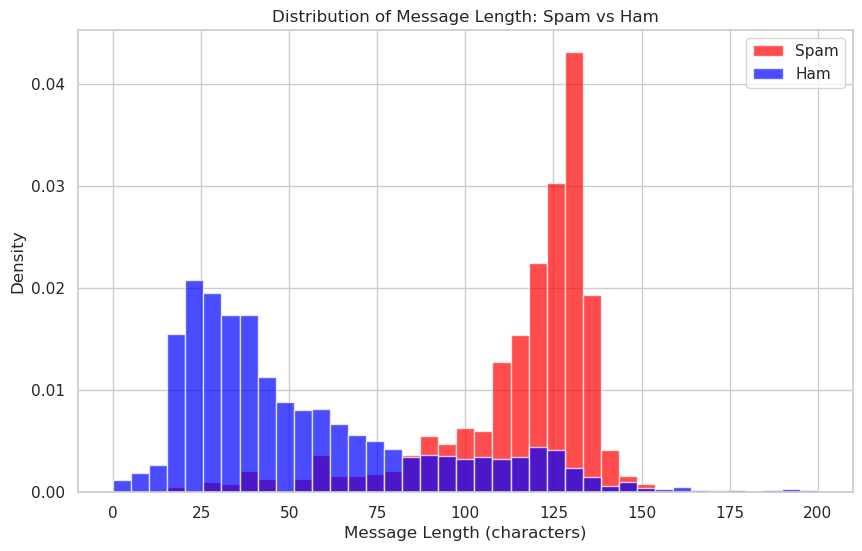

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Create body_len column if it doesn't exist
if 'body_len' not in data.columns:
    data['body_len'] = data['body_text'].str.len().fillna(0)

# Set up the plot style
sns.set(rc={"figure.figsize": (10, 6)})
sns.set_style("whitegrid")

# Create the histogram
plt.figure(figsize=(10, 6))
bins = np.linspace(0, 200, 40)

plt.hist(data[data['label']=='spam']['body_len'], 
         bins=bins, alpha=0.7, density=True, label='Spam', color='red')
plt.hist(data[data['label']=='ham']['body_len'], 
         bins=bins, alpha=0.7, density=True, label='Ham', color='blue')

plt.legend(loc='upper right')
plt.xlabel('Message Length (characters)')
plt.ylabel('Density')
plt.title('Distribution of Message Length: Spam vs Ham')
plt.show()

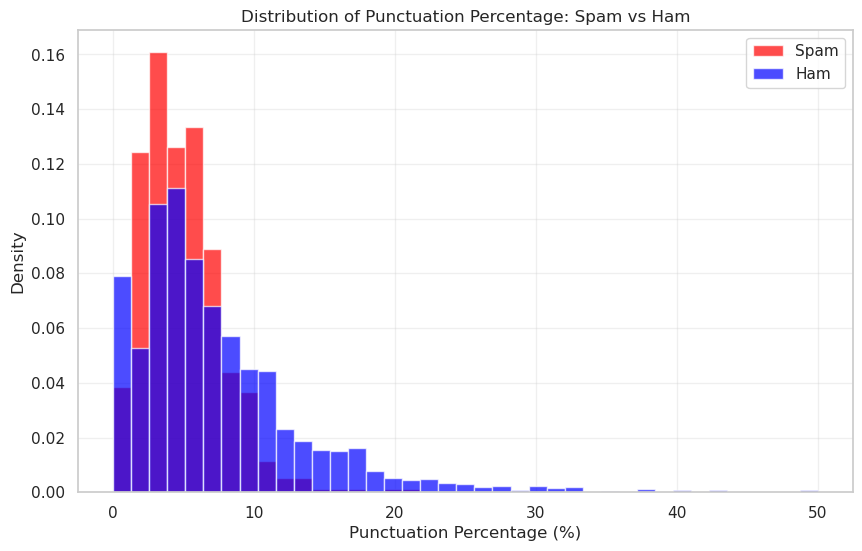

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import string

# Create punct% column if it doesn't exist
if 'punct%' not in data.columns:
    def punct_percentage(text):
        if pd.isnull(text) or text == '':
            return 0
        text_str = str(text)
        punct_count = sum(1 for char in text_str if char in string.punctuation)
        return (punct_count / len(text_str)) * 100
    
    data['punct%'] = data['body_text'].apply(punct_percentage)

# Create the plot
plt.figure(figsize=(10, 6))
bins = np.linspace(0, 50, 40)

plt.hist(data[data['label']=='spam']['punct%'], 
         bins=bins, alpha=0.7, density=True, label='Spam', color='red')
plt.hist(data[data['label']=='ham']['punct%'], 
         bins=bins, alpha=0.7, density=True, label='Ham', color='blue')

plt.legend(loc='upper right')
plt.xlabel('Punctuation Percentage (%)')
plt.ylabel('Density')
plt.title('Distribution of Punctuation Percentage: Spam vs Ham')
plt.grid(True, alpha=0.3)
plt.show()

In [29]:
from sklearn.model_selection import train_test_split

X=data[['body_text', 'body_len', 'punct%']]
y=data['label']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [30]:
tfidf_vect = TfidfVectorizer(analyzer=clean_text)
tfidf_vect_fit = tfidf_vect.fit(X_train['body_text'])

tfidf_train = tfidf_vect_fit.transform(X_train['body_text'])
tfidf_test = tfidf_vect_fit.transform(X_test['body_text'])

X_train_vect = pd.concat([X_train[['body_len', 'punct%']].reset_index(drop=True), 
           pd.DataFrame(tfidf_train.toarray())], axis=1)
X_test_vect = pd.concat([X_test[['body_len', 'punct%']].reset_index(drop=True), 
           pd.DataFrame(tfidf_test.toarray())], axis=1)

X_train_vect.head()

,body_len,punct%,0,1,2,3,4,5,6,7,...,7144,7145,7146,7147,7148,7149,7150,7151,7152,7153
0,83,2.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,83,7.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,38,5.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,77,1.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,126,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
! pip install yellowbrick

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


Precision: 1.0 / Recall: 0.852 / F1-Score: 0.92 / Accuracy: 98.027%


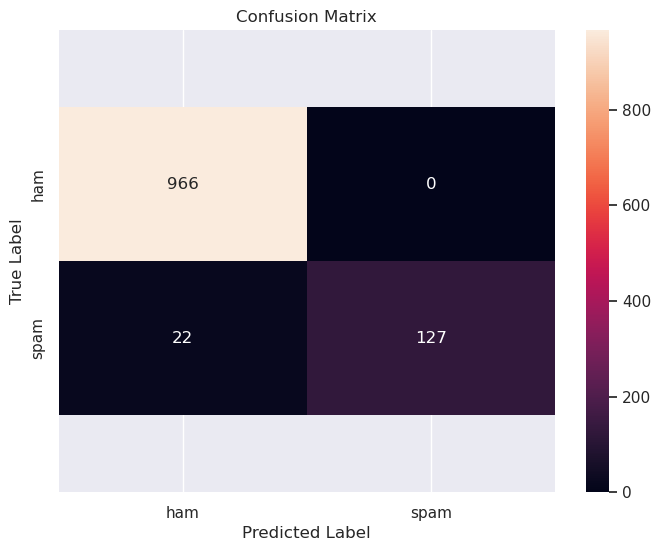

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Convert feature names to strings if they exist
if hasattr(X_train_vect, 'columns'):
    X_train_vect.columns = X_train_vect.columns.astype(str)
    X_test_vect.columns = X_test_vect.columns.astype(str)

# If using sparse matrices, convert feature names before creating the matrix
# Initialize and train the Random Forest classifier
rf = RandomForestClassifier(n_estimators=150, max_depth=None, n_jobs=-1)
rf_model = rf.fit(X_train_vect, y_train)

# Make predictions
y_pred = rf_model.predict(X_test_vect)

# Calculate metrics
precision = precision_score(y_test, y_pred, pos_label='spam')
recall = recall_score(y_test, y_pred, pos_label='spam')
fscore = f1_score(y_test, y_pred, pos_label='spam')
accuracy = accuracy_score(y_test, y_pred)

print('Precision: {} / Recall: {} / F1-Score: {} / Accuracy: {}%'.format(
    round(precision, 3), round(recall, 3), round(fscore, 3), round(accuracy * 100, 3)))

# Create confusion matrix plot
sns.set(rc={"figure.figsize": (8, 6)})
cm = confusion_matrix(y_test, y_pred)
class_label = ["ham", "spam"]
df_cm = pd.DataFrame(cm, index=class_label, columns=class_label)
ax = sns.heatmap(df_cm, annot=True, fmt='d')
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

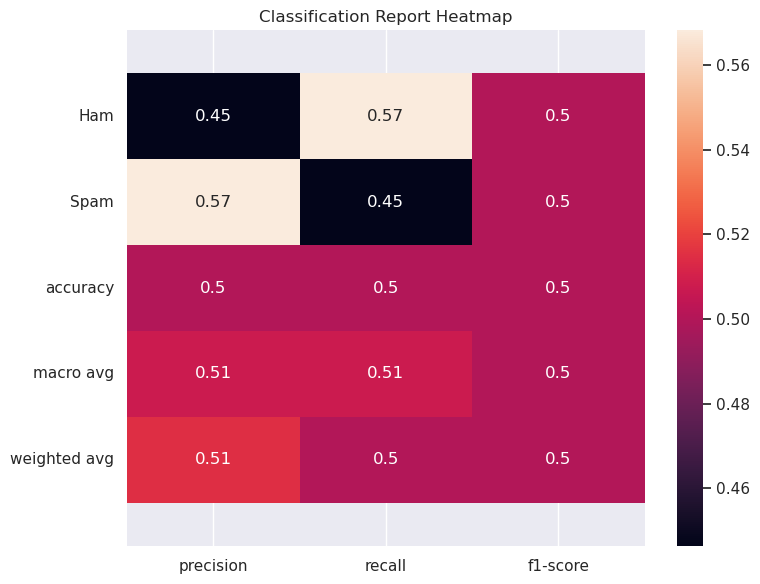

In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Generate sample data
np.random.seed(42)  # For reproducible results
true = np.random.randint(0, 2, size=100)  # Changed to binary (0,1) for Ham/Spam classification
pred = np.random.randint(0, 2, size=100)

# Use the generated variables
clf_report = classification_report(true,  # Use 'true' instead of 'y_test'
                                   pred,  # Use 'pred' instead of 'y_pred'
                                   target_names=target_names,
                                   output_dict=True)

# Create the heatmap
plt.figure(figsize=(8, 6))
ax = sns.heatmap(pd.DataFrame(clf_report).iloc[:-1, :].T, annot=True)
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)
plt.title('Classification Report Heatmap')
plt.tight_layout()
plt.show()

In [35]:
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       1.00      0.85      0.92       149

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115

